# EEG Band Power Analysis

This notebook demonstrates how to compute and visualize **band power** from NeuraDock EEG recordings.

## Background

EEG signals are traditionally decomposed into five canonical frequency bands, each associated with different brain states:

| Band | Frequency (Hz) | Typical Association |
|------|----------------|---------------------|
| **Delta** | 0.5 – 4 | Deep sleep, unconsciousness |
| **Theta** | 4 – 8 | Drowsiness, light sleep, meditation |
| **Alpha** | 8 – 13 | Relaxed wakefulness, eyes-closed (occipital) |
| **Beta**  | 13 – 30 | Active thinking, alert focus, motor activity |
| **Gamma** | 30 – 100 | High-level cognitive processing, binding |

By calculating the power within each band, we can quantify the spectral signature of a given mental state.

## Dataset

- `rest_20251024160452_2m12s.txt` — Resting-state recording (~2 min 13 s, 250 Hz, 7 channels)
- `task_20251024160748_2m33s.txt` — Task-state recording (~2 min 34 s, 250 Hz, 7 channels) *(used for comparison)*

## Pipeline
1. Load raw data
2. Preprocess (notch + band-pass filter)
3. Compute Welch PSD per channel
4. Extract absolute & relative band power
5. Visualize: spectrum, band-power bars, time–frequency spectrogram
6. (Bonus) Rest vs. Task comparison


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# NeuraDock data loader
from Neuradock_library import text2data_bluetooth

print("Libraries loaded.")


Libraries loaded.


In [2]:
# ------------------------------------------------------------------
# Load resting-state and task-state data
# ------------------------------------------------------------------
rest_data = text2data_bluetooth("rest_20251024160452_2m12s.txt")
task_data = text2data_bluetooth("task_20251024160748_2m33s.txt")

fs = 250  # Sampling rate
n_channels = rest_data.shape[0]

print(f"Rest data shape : {rest_data.shape}  ({rest_data.shape[1]/fs:.1f} s)")
print(f"Task data shape : {task_data.shape}  ({task_data.shape[1]/fs:.1f} s)")
print(f"Channels        : {n_channels}")
print(f"Sampling rate   : {fs} Hz")


Rest data shape : (7, 33145)  (132.6 s)
Task data shape : (7, 38435)  (153.7 s)
Channels        : 7
Sampling rate   : 250 Hz


## Step 1: Preprocessing

Before power analysis we apply two filters:
- **Notch filter** (49–51 Hz) to suppress 50 Hz power-line interference
- **Band-pass filter** (0.5–100 Hz) to remove DC drift and high-frequency noise


In [3]:
# ------------------------------------------------------------------
# Preprocessing: notch + band-pass
# ------------------------------------------------------------------
def preprocess_eeg(data, fs):
    """Apply notch (50 Hz) and band-pass (0.5-100 Hz) filters."""
    # Notch filter
    b_notch, a_notch = signal.iirnotch(50.0, 30.0, fs)
    data_notch = signal.filtfilt(b_notch, a_notch, data, axis=1)
    
    # Band-pass filter (0.5 - 100 Hz)
    b_bp, a_bp = signal.butter(4, [0.5, 100.0], btype="bandpass", fs=fs)
    data_bp = signal.filtfilt(b_bp, a_bp, data_notch, axis=1)
    
    return data_bp

rest_clean = preprocess_eeg(rest_data, fs)
task_clean = preprocess_eeg(task_data, fs)

print("Preprocessing complete.")


Preprocessing complete.


## Step 2: Power Spectral Density (Welch)

We use Welch's method to estimate the PSD for each channel.  
A 2-second Hamming window with 50 % overlap provides a good balance between frequency resolution and variance.


In [4]:
# ------------------------------------------------------------------
# Compute Welch PSD for every channel (resting state)
# ------------------------------------------------------------------
nperseg = fs * 2          # 2-second windows
noverlap = fs             # 50 % overlap

psd_rest = []
for ch in range(n_channels):
    f, psd = signal.welch(rest_clean[ch, :], fs, window="hann", nperseg=nperseg, noverlap=noverlap)
    psd_rest.append(psd)

psd_rest = np.array(psd_rest)  # shape: (7, n_freqs)
print(f"PSD shape: {psd_rest.shape}")
print(f"Frequency resolution: {f[1]-f[0]:.3f} Hz")


PSD shape: (7, 251)
Frequency resolution: 0.500 Hz


## Step 3: Band Power Extraction

Define the five canonical bands and compute:
- **Absolute power** — integrated PSD within each band (μV²)
- **Relative power** — absolute power divided by total power (0.5–100 Hz), expressed as %


In [5]:
# ------------------------------------------------------------------
# Band definitions
# ------------------------------------------------------------------
BANDS = {
    "Delta": (0.5, 4.0),
    "Theta": (4.0, 8.0),
    "Alpha": (8.0, 13.0),
    "Beta":  (13.0, 30.0),
    "Gamma": (30.0, 100.0),
}

BAND_COLORS = {
    "Delta": "#3498db",
    "Theta": "#9b59b6",
    "Alpha": "#2ecc71",
    "Beta":  "#f1c40f",
    "Gamma": "#e74c3c",
}


def compute_band_power(psd_array, freqs, bands):
    """
    Compute absolute and relative band power.

    Returns
    -------
    abs_power : dict[str, np.ndarray]  — shape (n_channels,)
    rel_power : dict[str, np.ndarray]  — shape (n_channels,)
    """
    abs_power = {}
    rel_power = {}
    total_idx = (freqs >= 0.5) & (freqs <= 100.0)
    total_power = np.trapezoid(psd_array[:, total_idx], freqs[total_idx], axis=1)

    for name, (low, high) in bands.items():
        idx = (freqs >= low) & (freqs <= high)
        band_pwr = np.trapezoid(psd_array[:, idx], freqs[idx], axis=1)
        abs_power[name] = band_pwr
        rel_power[name] = 100.0 * band_pwr / total_power

    return abs_power, rel_power


abs_rest, rel_rest = compute_band_power(psd_rest, f, BANDS)

# Print a quick summary for Channel 1
ch = 0
print(f"Channel {ch+1} — Resting State Band Power:")
print("-" * 40)
for name in BANDS:
    print(f"  {name:6s}:  Abs = {abs_rest[name][ch]:8.2f} μV²  |  Rel = {rel_rest[name][ch]:5.2f} %")


Channel 1 — Resting State Band Power:
----------------------------------------
  Delta :  Abs =    84.12 μV²  |  Rel = 60.82 %
  Theta :  Abs =    15.10 μV²  |  Rel = 10.92 %
  Alpha :  Abs =    12.07 μV²  |  Rel =  8.73 %
  Beta  :  Abs =    16.84 μV²  |  Rel = 12.18 %
  Gamma :  Abs =    10.17 μV²  |  Rel =  7.36 %


## Step 4: Visualization — Spectrum & Band Power

### (a) Average PSD with band shading
### (b) Absolute & Relative band-power bar charts


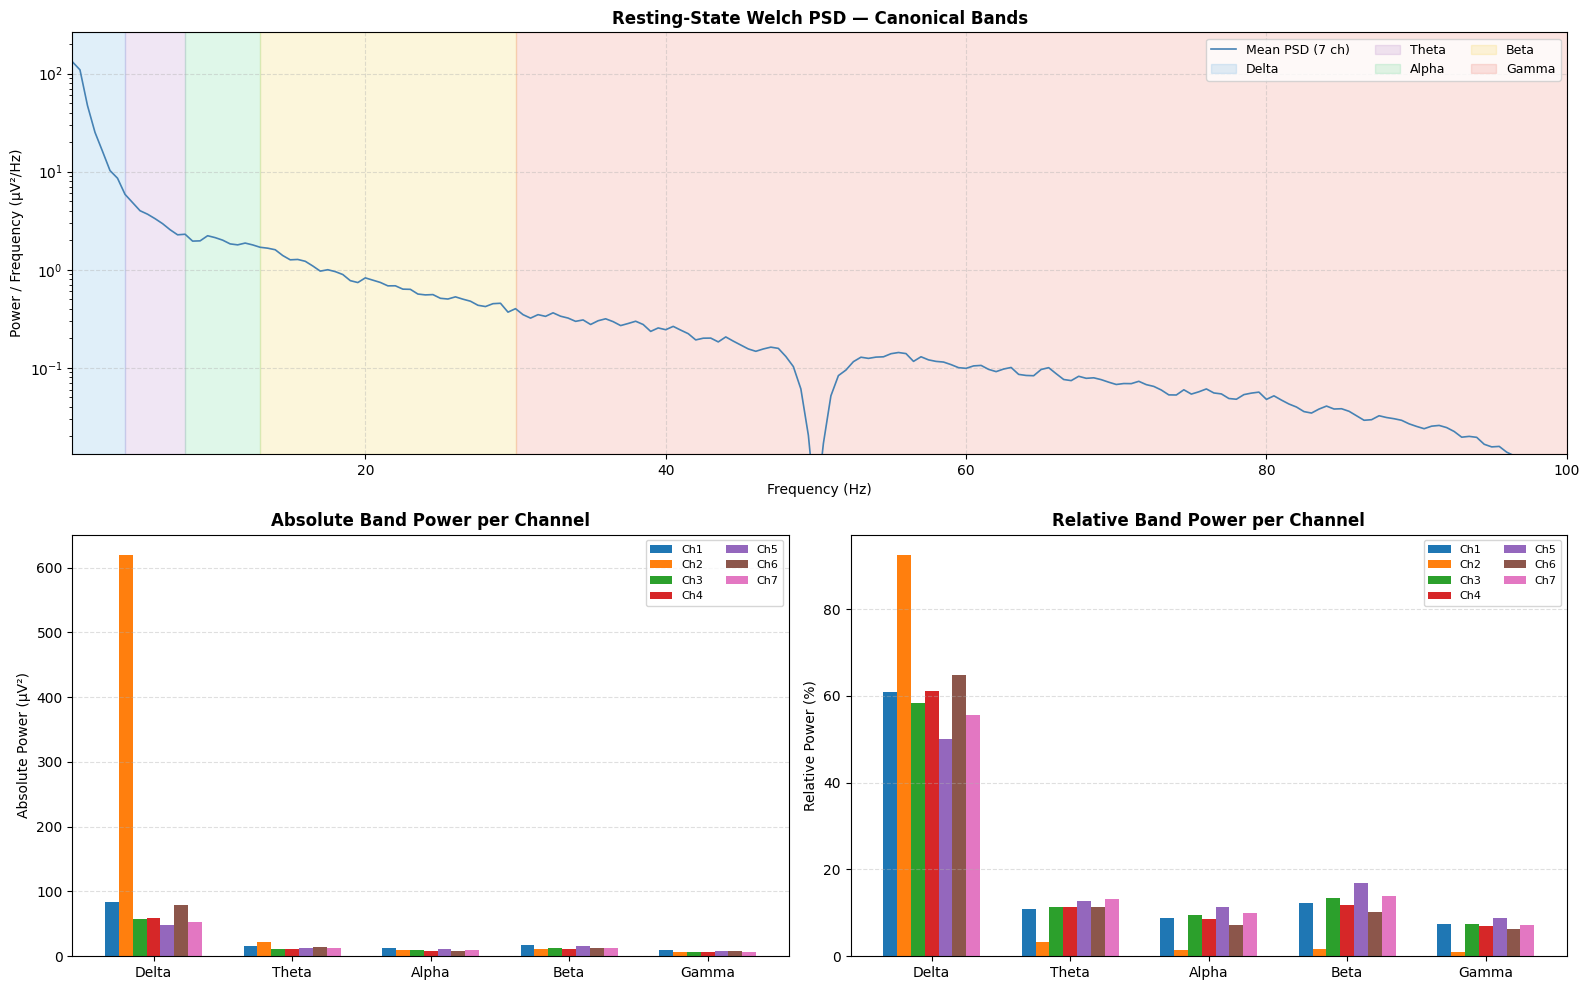

In [6]:
# ------------------------------------------------------------------
# Figure 1: Spectrum + Band Power Bars
# ------------------------------------------------------------------
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# --- (a) PSD with band shading ---
ax_psd = fig.add_subplot(gs[0, :])
mean_psd = np.mean(psd_rest, axis=0)
ax_psd.semilogy(f, mean_psd, color="steelblue", linewidth=1.2, label="Mean PSD (7 ch)")

for name, (low, high) in BANDS.items():
    ax_psd.axvspan(low, high, color=BAND_COLORS[name], alpha=0.15, label=f"{name}")

ax_psd.set_xlim(0.5, 100)
ax_psd.set_ylim(np.max(mean_psd) * 1e-4, np.max(mean_psd) * 2)
ax_psd.set_xlabel("Frequency (Hz)")
ax_psd.set_ylabel("Power / Frequency (μV²/Hz)")
ax_psd.set_title("Resting-State Welch PSD — Canonical Bands", fontweight="bold")
ax_psd.legend(loc="upper right", ncol=3, fontsize=9)
ax_psd.grid(True, linestyle="--", alpha=0.4)

# --- (b) Absolute band power (all channels) ---
ax_abs = fig.add_subplot(gs[1, 0])
x = np.arange(len(BANDS))
width = 0.1
for ch in range(n_channels):
    vals = [abs_rest[name][ch] for name in BANDS]
    ax_abs.bar(x + ch * width, vals, width, label=f"Ch{ch+1}")
ax_abs.set_xticks(x + width * 3)
ax_abs.set_xticklabels(list(BANDS.keys()))
ax_abs.set_ylabel("Absolute Power (μV²)")
ax_abs.set_title("Absolute Band Power per Channel", fontweight="bold")
ax_abs.legend(loc="upper right", ncol=2, fontsize=8)
ax_abs.grid(axis="y", linestyle="--", alpha=0.4)

# --- (c) Relative band power (all channels) ---
ax_rel = fig.add_subplot(gs[1, 1])
for ch in range(n_channels):
    vals = [rel_rest[name][ch] for name in BANDS]
    ax_rel.bar(x + ch * width, vals, width, label=f"Ch{ch+1}")
ax_rel.set_xticks(x + width * 3)
ax_rel.set_xticklabels(list(BANDS.keys()))
ax_rel.set_ylabel("Relative Power (%)")
ax_rel.set_title("Relative Band Power per Channel", fontweight="bold")
ax_rel.legend(loc="upper right", ncol=2, fontsize=8)
ax_rel.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


## Step 5: Time–Frequency Analysis (Spectrogram)

A spectrogram reveals how band power evolves over time.  
Here we focus on Channel 1 (typically occipital) during the resting state.


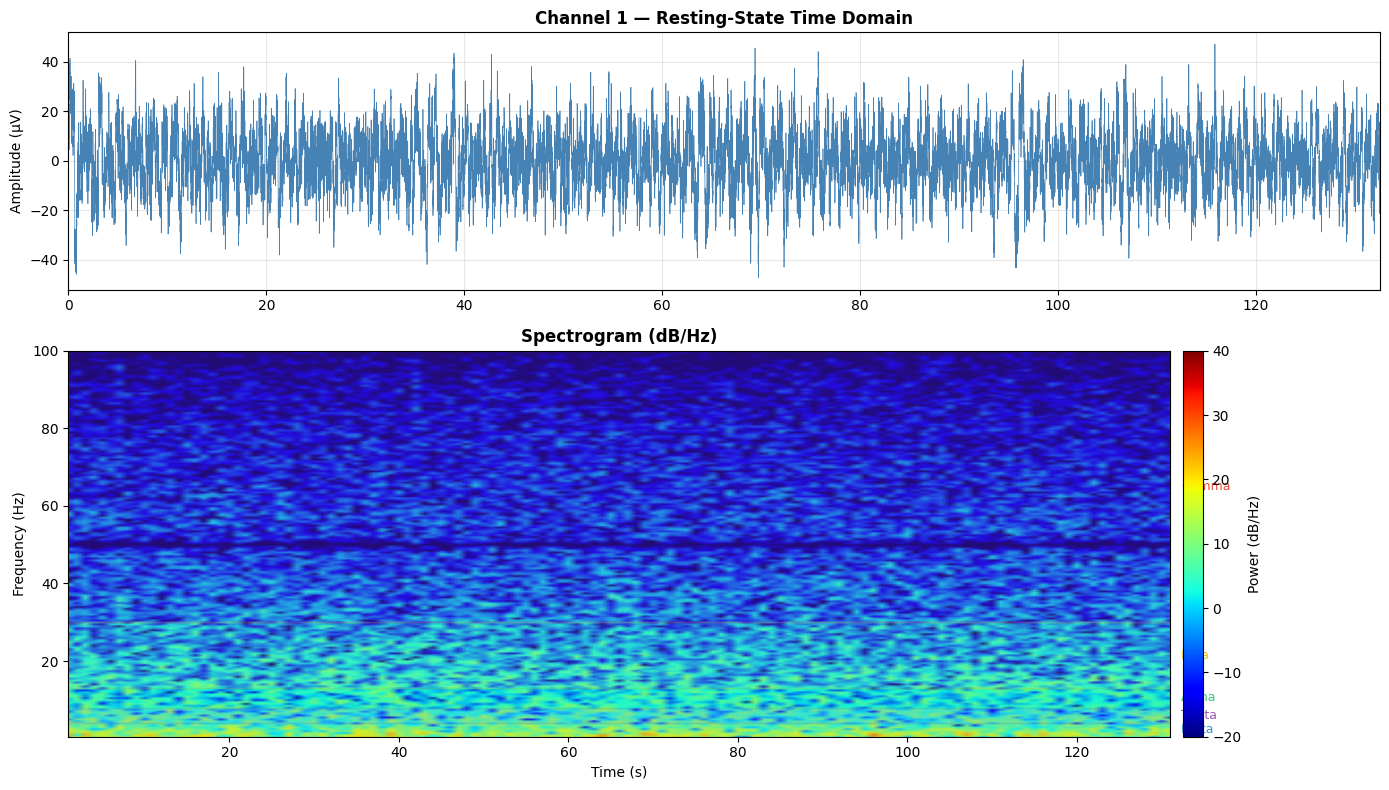

In [7]:
# ------------------------------------------------------------------
# Spectrogram for Channel 1 (resting state)
# ------------------------------------------------------------------
ch = 0
eeg_ch = rest_clean[ch, :]

# Compute spectrogram
f_spec, t_spec, Sxx = signal.spectrogram(
    eeg_ch, fs, window="hann", nperseg=fs*2, noverlap=fs, scaling="density"
)

# Convert to dB
Sxx_db = 10 * np.log10(Sxx + 1e-12)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [1, 1.5]})

# (a) Time-domain trace
ax = axes[0]
t = np.arange(len(eeg_ch)) / fs
ax.plot(t, eeg_ch, color="steelblue", linewidth=0.5)
ax.set_ylabel("Amplitude (μV)")
ax.set_title(f"Channel {ch+1} — Resting-State Time Domain", fontweight="bold")
ax.set_xlim(t[0], t[-1])
ax.grid(True, alpha=0.3)

# (b) Spectrogram
ax = axes[1]
im = ax.pcolormesh(t_spec, f_spec, Sxx_db, shading="gouraud", cmap="jet", vmin=-20, vmax=40)
ax.set_ylim(0.5, 100)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Spectrogram (dB/Hz)", fontweight="bold")

# Add band reference lines
for name, (low, high) in BANDS.items():
    ax.axhspan(low, high, color=BAND_COLORS[name], alpha=0.15)
    ax.text(t_spec[-1] * 1.01, (low + high) / 2, name, va="center", fontsize=9, color=BAND_COLORS[name])

fig.colorbar(im, ax=ax, pad=0.01, label="Power (dB/Hz)")
plt.tight_layout()
plt.show()


## Step 6: Rest vs. Task — Band Power Comparison

By comparing the same subject in resting and task states, we can observe **Alpha ERD** (Event-Related Desynchronization): Alpha power typically drops during cognitive tasks.


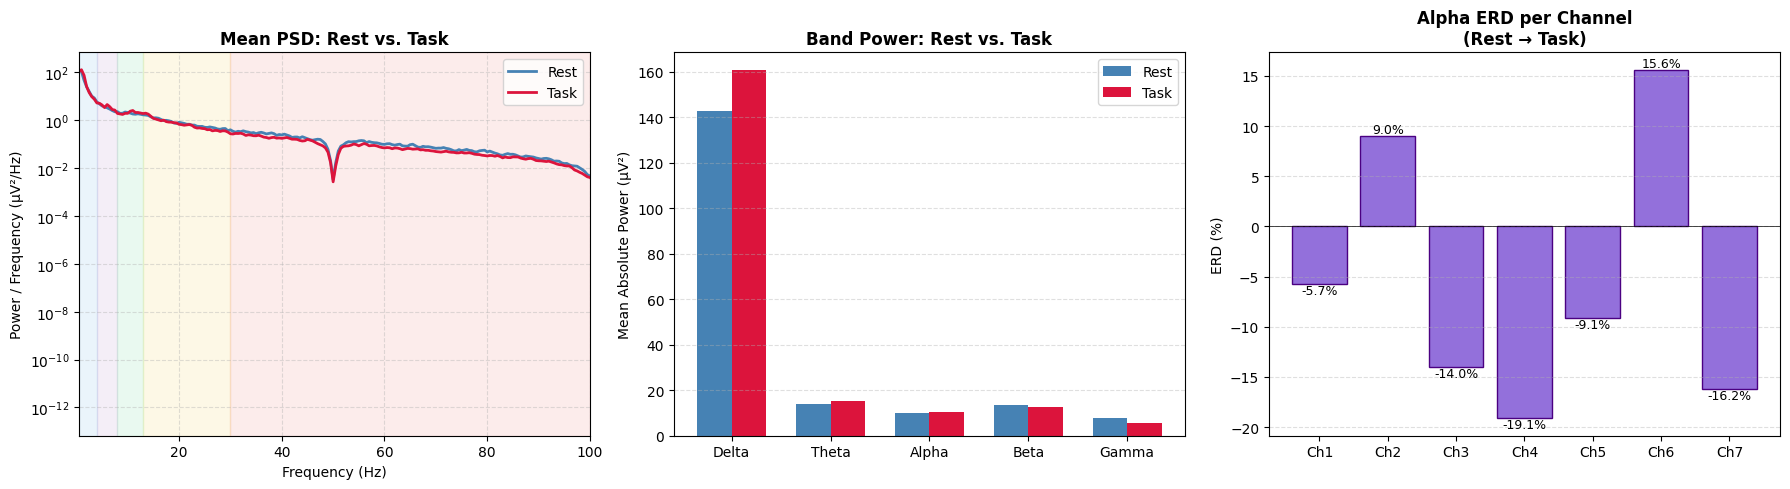


Rest vs. Task — Mean Band Power Summary
  Delta :  Rest =   142.82 μV²  |  Task =   160.68 μV²  |  Change = +12.50%
  Theta :  Rest =    13.85 μV²  |  Task =    15.17 μV²  |  Change =  +9.48%
  Alpha :  Rest =     9.78 μV²  |  Task =    10.34 μV²  |  Change =  +5.69%
  Beta  :  Rest =    13.59 μV²  |  Task =    12.71 μV²  |  Change =  -6.51%
  Gamma :  Rest =     7.75 μV²  |  Task =     5.80 μV²  |  Change = -25.17%


In [8]:
# ------------------------------------------------------------------
# Compute PSD for task state and compare bands
# ------------------------------------------------------------------
psd_task = []
for ch in range(n_channels):
    f_task, psd = signal.welch(task_clean[ch, :], fs, window="hann", nperseg=nperseg, noverlap=noverlap)
    psd_task.append(psd)
psd_task = np.array(psd_task)

abs_task, rel_task = compute_band_power(psd_task, f_task, BANDS)

# ------------------------------------------------------------------
# Comparison figure: Rest vs Task
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Mean PSD overlay
ax = axes[0]
ax.semilogy(f, np.mean(psd_rest, axis=0), color="steelblue", linewidth=2, label="Rest")
ax.semilogy(f_task, np.mean(psd_task, axis=0), color="crimson", linewidth=2, label="Task")
for name, (low, high) in BANDS.items():
    ax.axvspan(low, high, color=BAND_COLORS[name], alpha=0.1)
ax.set_xlim(0.5, 100)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power / Frequency (μV²/Hz)")
ax.set_title("Mean PSD: Rest vs. Task", fontweight="bold")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)

# (b) Absolute power comparison
ax = axes[1]
x = np.arange(len(BANDS))
width = 0.35
rest_vals = [np.mean(abs_rest[name]) for name in BANDS]
task_vals = [np.mean(abs_task[name]) for name in BANDS]
ax.bar(x - width/2, rest_vals, width, label="Rest", color="steelblue")
ax.bar(x + width/2, task_vals, width, label="Task", color="crimson")
ax.set_xticks(x)
ax.set_xticklabels(list(BANDS.keys()))
ax.set_ylabel("Mean Absolute Power (μV²)")
ax.set_title("Band Power: Rest vs. Task", fontweight="bold")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

# (c) Alpha ERD bar chart (per channel)
ax = axes[2]
alpha_rest_ch = abs_rest["Alpha"]
alpha_task_ch = abs_task["Alpha"]
erd_pct = 100.0 * (alpha_rest_ch - alpha_task_ch) / alpha_rest_ch
bars = ax.bar([f"Ch{i+1}" for i in range(n_channels)], erd_pct, color="mediumpurple", edgecolor="indigo")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("ERD (%)")
ax.set_title("Alpha ERD per Channel\n(Rest → Task)", fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.4)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f"{height:.1f}%", ha="center", va="bottom" if height > 0 else "top", fontsize=9)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "=" * 50)
print("Rest vs. Task — Mean Band Power Summary")
print("=" * 50)
for name in BANDS:
    r = np.mean(abs_rest[name])
    t = np.mean(abs_task[name])
    change = 100.0 * (t - r) / r
    print(f"  {name:6s}:  Rest = {r:8.2f} μV²  |  Task = {t:8.2f} μV²  |  Change = {change:+6.2f}%")
print("=" * 50)


## Summary

In this notebook we:
1. Loaded and preprocessed resting-state and task-state EEG data.
2. Computed Welch PSD and extracted absolute / relative power for the five canonical bands.
3. Visualized the spectrum, band-power distributions, and time–frequency evolution.
4. Compared resting vs. task conditions, revealing **Alpha ERD** (power suppression during cognitive load).

### Key Takeaways
- **Relative power** normalizes across recordings and is useful for cross-session comparison.
- **Alpha ERD** is a robust marker of cognitive engagement: expect lower Alpha during tasks.
- Always preprocess (notch + band-pass) before power analysis to avoid contamination from line noise and DC drift.
